In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("../data/features_target.csv")

data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])
data.rename(columns = {'Unnamed: 0':'Date'}, inplace=True) 
data.set_index('Date', inplace = True)

returns = 100 * data['SP500'].pct_change().dropna()
returns = returns.drop(returns[returns == 0].index)

In [10]:
split_date = '2018-01-01'

train = returns[returns.index < split_date].copy()
test = returns[returns.index >= split_date].copy()

In [19]:
num_lags = 20

def make_lags(series, lags):
    df = pd.DataFrame({'y': series})
    for i in range(1, lags+1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

train_with_lags = make_lags(train, lags=num_lags)
test_with_lags = make_lags(test, lags=num_lags)

X_train = train_with_lags.drop(columns='y')
y_train = train_with_lags['y']

X_test = test_with_lags.drop(columns='y')
y_test = test_with_lags['y']

In [26]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

model = DummyRegressor()
model.fit(X_train, y_train)
y_pred_train_dummy = model.predict(X_train)
y_pred_test_dummy = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train_dummy)
mse_test = mean_squared_error(y_test, y_pred_test_dummy)
print(f"MSE Train: {mse_train} Test: {mse_test}")

MSE Train: 0.8104908610390795 Test: 0.9590746775244275


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train_lr = model.predict(X_train)
y_pred_test_lr = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train_lr)
mse_test = mean_squared_error(y_test, y_pred_test_lr)
print(f"MSE Train: {mse_train} Test: {mse_test}")

MSE Train: 0.7863439161505414 Test: 0.9745425773822112


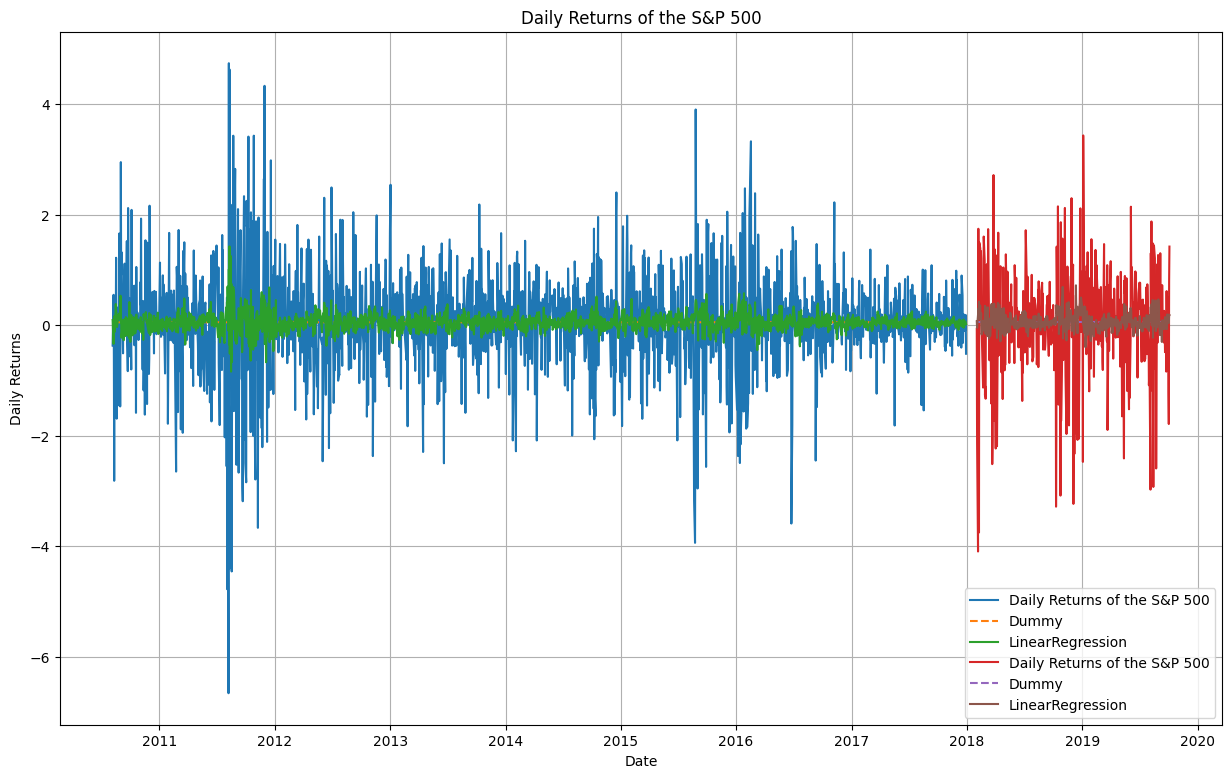

In [29]:
plt.figure(figsize=(15,9))
plt.grid()
plt.plot(y_train.index, y_train, label='Daily Returns of the S&P 500')
plt.plot(y_train.index, y_pred_train_dummy, label='Dummy', linestyle='--')
plt.plot(y_train.index, y_pred_train_lr, label='LinearRegression')

plt.plot(y_test.index, y_test, label='Daily Returns of the S&P 500')
plt.plot(y_test.index, y_pred_test_dummy, label='Dummy', linestyle='--')
plt.plot(y_test.index, y_pred_test_lr, label='LinearRegression')

plt.title("Daily Returns of the S&P 500")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.legend()
plt.show()